In [34]:
#! pip install pctk

In [1]:
from pctk import multicellds
import pandas as pd
import matplotlib.pyplot as plt
from plot_df_journal_style_ext import plot_panels

In [172]:
output_path = "../../../../output/"

In [181]:
# Creating a MCDS reader
reader = multicellds.MultiCellDS(output_folder=output_path)

In [182]:
data = []
for t, a in reader.microenvironment_as_matrix_iterator():
    data.append((t/60, (a[5].sum() / len(a[5])), (a[6].sum() / len(a[6])), (a[4].sum() / len(a[4])) ))

In [183]:
reader.microenvironment_columns

[('oxygen', 'dimensionless', '0'),
 ('glucose', 'dimensionless', '1'),
 ('acetate', 'dimensionless', '2'),
 ('CO2', 'dimensionless', '3')]

<Axes: xlabel='time'>

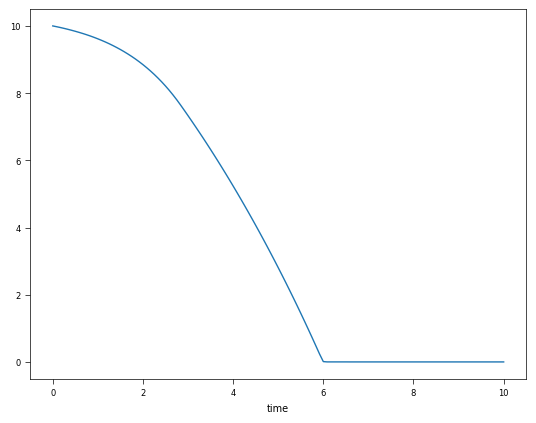

In [184]:
d_substrates = pd.DataFrame(data=data, columns=["time", "glucose", "acetate", "oxygen"]).set_index("time")
d_substrates["glucose"].plot()

In [185]:
data = []
# Dimensions from your XML
x_range = 250.0 - (-250.0) # 500 um
y_range = 250.0 - (-250.0) # 500 um
z_range = 10.0 - (-10.0)   # 20 um

total_domain_volume_um3 = x_range * y_range * z_range # 5,000,000 um3
reactor_volume_L = total_domain_volume_um3 / 1e15     # 5.0e-9 L
for t, a in reader.cells_as_matrix_iterator():
    total_volume = a[:,4].sum() # um3
    scaled_volume = total_volume / 10**12 # mL
    density = 1.04 # g/ml
    solid_fraction = 0.25
    biomass = scaled_volume * density * solid_fraction / reactor_volume_L
    #print("total volume is ", total_volume)
    data.append((t/60, a[:,-2].mean(), a.shape[0], biomass))

<Axes: xlabel='time'>

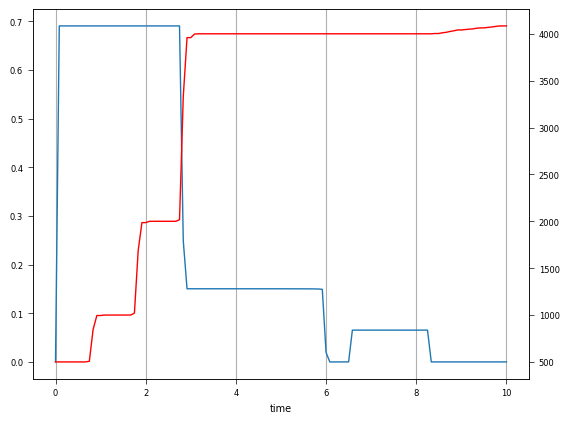

In [186]:
d_cells = pd.DataFrame(data=data, columns=["time", "growth_rate", "n_cells", "total_biomass"]).set_index("time")
ax = d_cells["growth_rate"].plot()
ax.grid(axis="x")
ax = ax.twinx()
d_cells["n_cells"].plot(ax=ax, c="red")

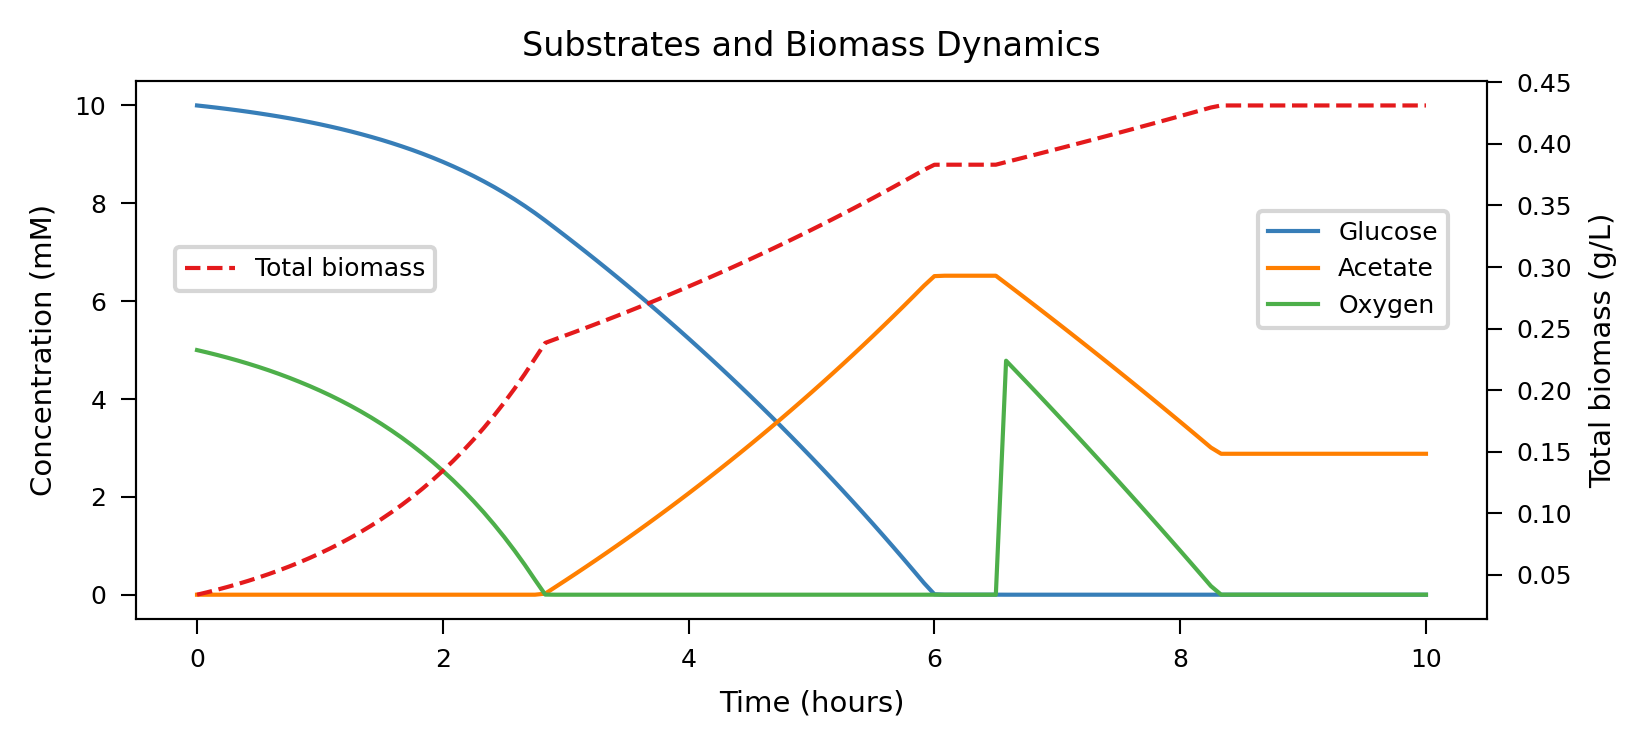

In [199]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Nature style settings
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
mpl.rcParams['font.size'] = 7
mpl.rcParams['axes.labelsize'] = 7
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['xtick.labelsize'] = 6
mpl.rcParams['ytick.labelsize'] = 6
mpl.rcParams['legend.fontsize'] = 6
mpl.rcParams['figure.titlesize'] = 8
mpl.rcParams['lines.linewidth'] = 1.0
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['xtick.major.width'] = 0.5
mpl.rcParams['ytick.major.width'] = 0.5

# Figure size for single column (approx 89mm / 3.5 inches)
fig_width = 5.5  # inches
fig_height = 2.5 # inches

# Create the figure and the first axis (left)
fig, ax1 = plt.subplots(figsize=(fig_width, fig_height), dpi=300)

# Colors
colors = {'glucose': '#377eb8', 'acetate': '#ff7f00', 'oxygen': '#4daf4a', 'biomass': '#e41a1c'}

# --- LEFT AXIS (Substrates) ---
l1, = ax1.plot(d_substrates.index, d_substrates["glucose"], label="Glucose", color=colors['glucose'])
l2, = ax1.plot(d_substrates.index, d_substrates["acetate"], label="Acetate", color=colors['acetate'])
l3, = ax1.plot(d_substrates.index, d_substrates["oxygen"], label="Oxygen", color=colors['oxygen'])

ax1.set_xlabel("Time (hours)")
ax1.set_ylabel("Concentration (mM)")

# --- RIGHT AXIS (Biomass) ---
ax2 = ax1.twinx()
l4, = ax2.plot(d_cells.index, d_cells["total_biomass"], label="Total biomass", color=colors['biomass'], linestyle="--")
ax2.set_ylabel("Total biomass (g/L)")

# --- 4-AXIS "BOX" STYLE ---
# To have a full box (4 spines), we ensure visibility is True on both axes
# We generally keep the ticks only on the relevant sides, but show the spine lines.
ax1.spines['top'].set_visible(True)
ax2.spines['top'].set_visible(True) # Overlays ax1, ensures top line is drawn

# --- DUAL LEGENDS ---

# Legend 1: Substrates (Left side)
lines_1 = [l1, l2, l3]
labels_1 = [l.get_label() for l in lines_1]
# 'loc' controls position. 'center left' places it inside the plot on the left.
# bbox_to_anchor can be used to move it outside if preferred.
leg1 = ax1.legend(lines_1, labels_1, loc="center right", bbox_to_anchor=(0.98, 0.65), frameon=True, fancybox=True)

# Legend 2: Biomass (Right side)
lines_2 = [l4]
labels_2 = [l.get_label() for l in lines_2]
leg2 = ax2.legend(lines_2, labels_2, loc="center left", bbox_to_anchor=(0.02, 0.65), frameon=True, fancybox=True)

# Important: When using dual legends on the same axis object (or shared axes), 
# sometimes the second legend overwrites the first. 
# However, since we attached leg1 to ax1 and leg2 to ax2, they naturally coexist.
# If you ever need two legends on ONE axis, you must use ax.add_artist(first_legend).

plt.title("Substrates and Biomass Dynamics")
plt.tight_layout()
plt.show()